In [25]:
import torch
from torch import distributions

# let's generate a data set from a simple linear transformation with multi guassian noise

n = 5000
x = torch.distributions.MultivariateNormal(torch.zeros(2), torch.eye(2)).sample((n,))
weights = torch.tensor([0.5, 0.5])
means = (x * weights).sum(dim=1)
y = distributions.Normal(
    means, 0.1
).sample()  # Remove (n,) to get one sample per distribution
y = y.unsqueeze(-1)  # Add dimension to match model output: [n] -> [n, 1]
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: torch.Size([5000, 2])
y shape: torch.Size([5000, 1])


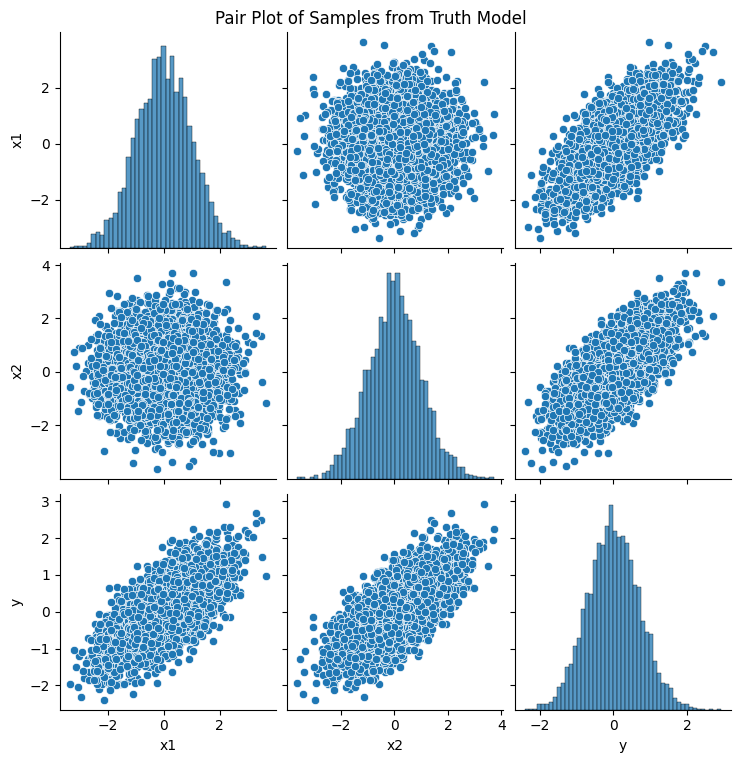

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a dataframe for visualization
data = pd.DataFrame(
    {
        "x1": x[:, 0].numpy(),
        "x2": x[:, 1].numpy(),
        "y": y[:, 0].numpy(),
    }  # y is now [n, 1], so use [:, 0]
)

# Create pair plot
sns.pairplot(data)
plt.suptitle("Pair Plot of Samples from Truth Model", y=1.01)
plt.show()

In [27]:
from torch_bdn import BayesianNet
from torch_bdn.sampling import Sampler
from torch_dln import dln


# Define a simple prior function - Normal(0, 1) for all parameters
def simple_prior(param):
    """Simple independent Normal(0, 1) prior for each parameter"""
    return torch.distributions.Normal(0.0, 1.0).log_prob(param).sum()


# Create FRESH DLN model and Bayesian wrapper (to pick up latest fixes)
print("Creating fresh model with updated BayesianNet...")
toy_dln = dln([2, 3, 1])
toy_bdln = BayesianNet(
    model=toy_dln, loss_fn=torch.nn.MSELoss(), prior_logp=simple_prior
)

result = Sampler(toy_bdln, x=x, y=y).sample(num_samples=1000, n_burnin=10000, lr=0.9)

Creating fresh model with updated BayesianNet...
Working with parameters of shape torch.Size([9])
Data shapes - x: torch.Size([5000, 2]), y: torch.Size([5000, 1])


Testing different learning rates for SGLD sampling...
  Sampling with LR: 0.1
Working with parameters of shape torch.Size([9])
Data shapes - x: torch.Size([5000, 2]), y: torch.Size([5000, 1])
  Sampling with LR: 0.5
Working with parameters of shape torch.Size([9])
Data shapes - x: torch.Size([5000, 2]), y: torch.Size([5000, 1])
  Sampling with LR: 0.9
Working with parameters of shape torch.Size([9])
Data shapes - x: torch.Size([5000, 2]), y: torch.Size([5000, 1])
  Sampling with LR: 1.5
Working with parameters of shape torch.Size([9])
Data shapes - x: torch.Size([5000, 2]), y: torch.Size([5000, 1])
Running MLE optimization with trajectory tracking...


<Figure size 1400x1200 with 0 Axes>

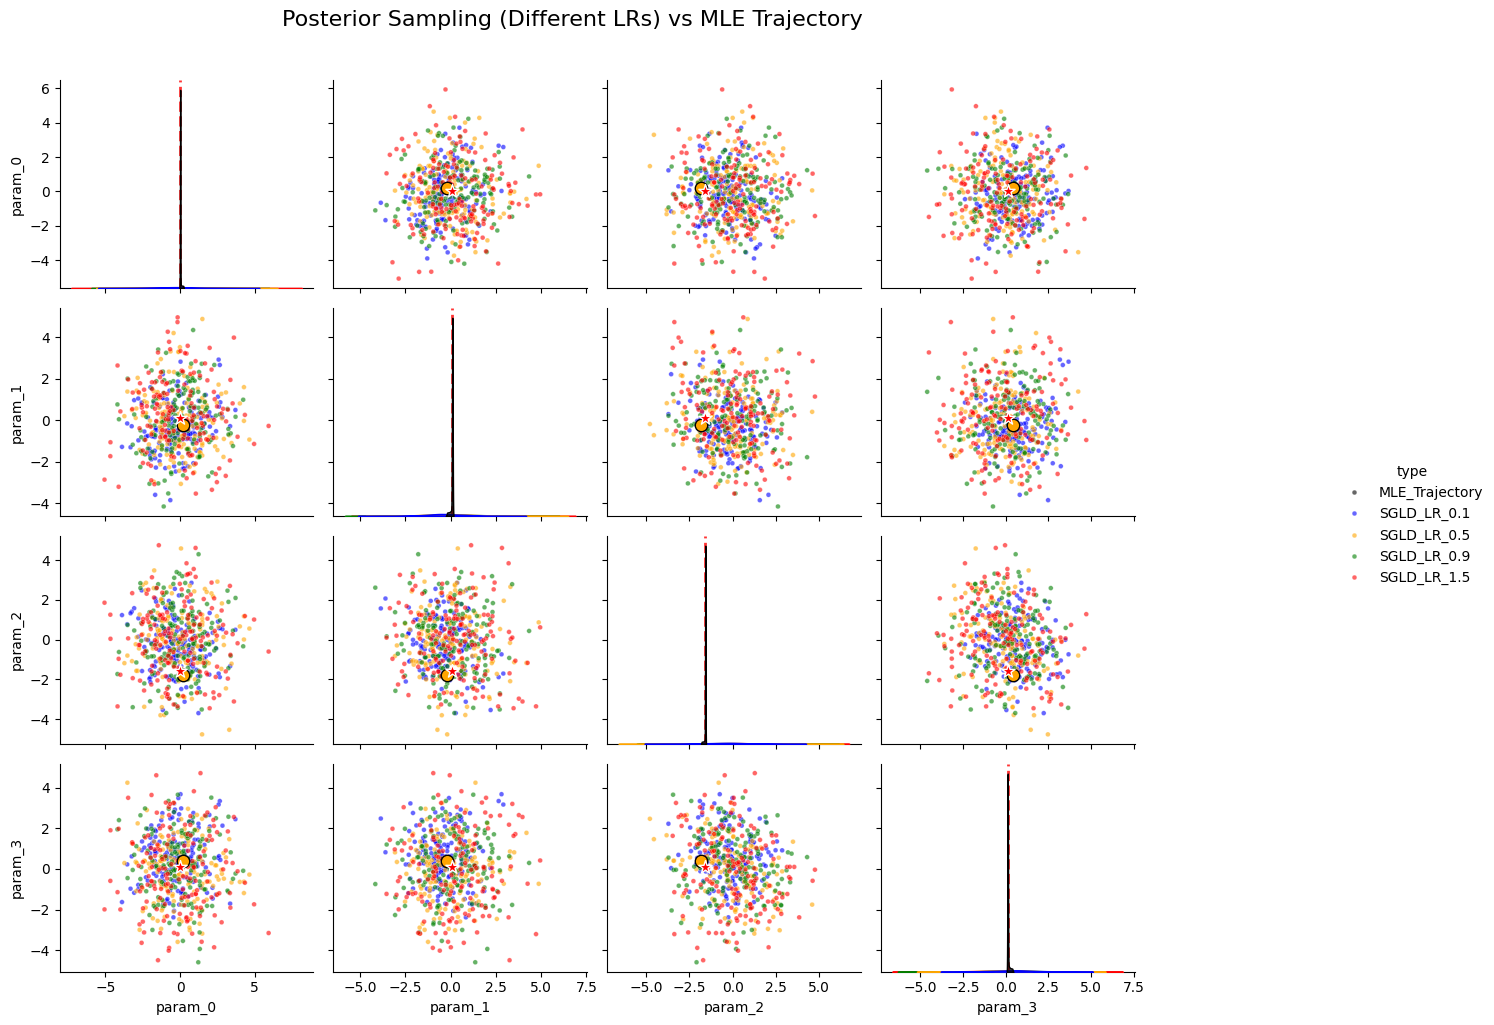


=== Analysis Summary ===
True generative weights: tensor([[0.5000, 0.5000]])
MLE effective weights: tensor([[0.4992, 0.4990]], grad_fn=<MmBackward0>)
MLE error: 0.001050

Learning Rate Effects:
  LR 0.1: Avg std = 1.306, Avg range = 7.976
  LR 0.5: Avg std = 1.568, Avg range = 9.802
  LR 0.9: Avg std = 1.618, Avg range = 11.608
  LR 1.5: Avg std = 1.797, Avg range = 11.543

MLE Trajectory: Traveled 0.820 in parameter space


In [31]:
# Comprehensive analysis: Different learning rates + MLE trajectory comparison
import torch.optim as optim
from torch_dln import dln

# Test different learning rates for posterior sampling
learning_rates = [0.1, 0.5, 0.9, 1.5]
results_by_lr = {}

print("Testing different learning rates for SGLD sampling...")
for lr in learning_rates:
    print(f"  Sampling with LR: {lr}")

    # Create fresh model and sampler
    test_dln = dln([2, 3, 1])
    test_bdln = BayesianNet(
        model=test_dln, loss_fn=torch.nn.MSELoss(), prior_logp=simple_prior
    )

    # Sample with this learning rate (reduced samples for faster execution)
    test_result = Sampler(test_bdln, x=x, y=y).sample(
        num_samples=1000, n_burnin=3000, lr=lr
    )

    test_samples = torch.stack(test_result["parameters"])
    results_by_lr[lr] = {"samples": test_samples}

# Run MLE optimization with trajectory tracking
print("Running MLE optimization with trajectory tracking...")
mle_model = dln([2, 3, 1])
optimizer = optim.Adam(mle_model.parameters(), lr=0.01)
mle_trajectory = []

for _ in range(300):  # Fewer epochs for cleaner visualization
    # Save current parameters
    current_params = torch.cat([p.data.flatten() for p in mle_model.parameters()])
    mle_trajectory.append(current_params.clone())

    # Optimization step
    optimizer.zero_grad()
    loss = torch.nn.MSELoss()(mle_model(x), y)
    loss.backward()
    optimizer.step()

mle_trajectory = torch.stack(mle_trajectory)  # [num_steps, num_params]

# Prepare data for visualization
n_params_viz = 4  # Show first 4 parameters
combined_data = []

# Add MLE trajectory as a "sample type"
mle_df = pd.DataFrame(
    mle_trajectory[:, :n_params_viz].numpy(),
    columns=[f"param_{i}" for i in range(n_params_viz)],
)
mle_df["type"] = "MLE_Trajectory"
combined_data.append(mle_df)

# Add samples from each learning rate
for lr in learning_rates:
    samples = results_by_lr[lr]["samples"]
    # Take subset to avoid overplotting
    n_subset = min(150, len(samples))
    indices = torch.randperm(len(samples))[:n_subset]
    subset_samples = samples[indices]

    lr_df = pd.DataFrame(
        subset_samples[:, :n_params_viz].numpy(),
        columns=[f"param_{i}" for i in range(n_params_viz)],
    )
    lr_df["type"] = f"SGLD_LR_{lr}"
    combined_data.append(lr_df)

# Combine all data
all_data_df = pd.concat(combined_data, ignore_index=True)

# Create comprehensive pair plot
plt.figure(figsize=(14, 12))
g = sns.pairplot(
    all_data_df,
    hue="type",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 12},
    diag_kws={"alpha": 0.7},
    palette={
        "MLE_Trajectory": "black",
        "SGLD_LR_0.1": "blue",
        "SGLD_LR_0.5": "orange",
        "SGLD_LR_0.9": "green",
        "SGLD_LR_1.5": "red",
    },
)

# Customize the plot to highlight MLE trajectory
for i in range(n_params_viz):
    for j in range(n_params_viz):
        ax = g.axes[i, j]
        if i != j:  # Off-diagonal: add trajectory path
            mle_data = all_data_df[all_data_df["type"] == "MLE_Trajectory"]
            ax.plot(
                mle_data[f"param_{j}"],
                mle_data[f"param_{i}"],
                "k-",
                linewidth=3,
                alpha=0.8,
                zorder=10,
                label="MLE Path",
            )
            # Add start and end markers
            ax.scatter(
                mle_data[f"param_{j}"].iloc[0],
                mle_data[f"param_{i}"].iloc[0],
                color="orange",
                s=80,
                marker="o",
                zorder=11,
                edgecolor="black",
                label="MLE Start",
            )
            ax.scatter(
                mle_data[f"param_{j}"].iloc[-1],
                mle_data[f"param_{i}"].iloc[-1],
                color="red",
                s=100,
                marker="*",
                zorder=12,
                edgecolor="white",
                label="MLE End",
            )
        else:  # Diagonal: add MLE final value
            mle_final = mle_trajectory[-1, i].item()
            ax.axvline(
                mle_final,
                color="red",
                linestyle="--",
                linewidth=2,
                alpha=0.8,
                label="MLE Final",
            )

g.fig.suptitle(
    "Posterior Sampling (Different LRs) vs MLE Trajectory", fontsize=16, y=1.02
)

# Adjust legend position to avoid overlap
legend = g._legend
if legend:
    legend.set_bbox_to_anchor((1.15, 0.5))
    legend.set_loc("center left")

plt.tight_layout()
plt.show()

# Analysis summary
print("\n=== Analysis Summary ===")
true_weights = torch.tensor([[0.5, 0.5]])
mle_effective = mle_model.layers[1].weight @ mle_model.layers[0].weight
print(f"True generative weights: {true_weights}")
print(f"MLE effective weights: {mle_effective}")
print(f"MLE error: {torch.abs(mle_effective - true_weights).max().item():.6f}")

print("\nLearning Rate Effects:")
for lr in learning_rates:
    samples = results_by_lr[lr]["samples"][:, :n_params_viz].numpy()
    param_std = samples.std(axis=0).mean()
    param_range = (samples.max(axis=0) - samples.min(axis=0)).mean()
    print(f"  LR {lr:3.1f}: Avg std = {param_std:.3f}, Avg range = {param_range:.3f}")

print(
    f"\nMLE Trajectory: Traveled {torch.norm(mle_trajectory[-1] - mle_trajectory[0]).item():.3f} in parameter space"
)